In [1]:
!pip install pandas numpy matplotlib seaborn scipy

In [2]:
from google.colab import files
uploaded = files.upload()

Saving startup_data (1).csv to startup_data (1).csv


In [9]:
import pandas as pd

df = pd.read_csv('startup_data (1).csv')

df.head()

,Startup Name,Industry,Funding Rounds,Funding Amount (M USD),Valuation (M USD),Revenue (M USD),Employees,Market Share (%),Profitable,Year Founded,Region,Exit Status
0,Startup_1,IoT,1,101.09,844.75,67.87,1468,5.20,0,2006,Europe,Private
1,Startup_2,EdTech,1,247.62,3310.83,75.65,3280,8.10,1,2003,South America,Private
2,Startup_3,EdTech,1,109.24,1059.37,84.21,4933,2.61,1,1995,South America,Private
3,Startup_4,Gaming,5,10.75,101.90,47.08,1059,2.53,0,2003,South America,Private
4,Startup_5,IoT,4,249.28,850.11,50.25,1905,4.09,0,1997,Europe,Acquired


In [5]:
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())

(500, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Startup Name            500 non-null    object 
 1   Industry                500 non-null    object 
 2   Funding Rounds          500 non-null    int64  
 3   Funding Amount (M USD)  500 non-null    float64
 4   Valuation (M USD)       500 non-null    float64
 5   Revenue (M USD)         500 non-null    float64
 6   Employees               500 non-null    int64  
 7   Market Share (%)        500 non-null    float64
 8   Profitable              500 non-null    int64  
 9   Year Founded            500 non-null    int64  
 10  Region                  500 non-null    object 
 11  Exit Status             500 non-null    object 
dtypes: float64(4), int64(4), object(4)
memory usage: 47.0+ KB
None
Startup Name              0
Industry                  0
Funding Rounds     

In [7]:
df = df.drop_duplicates()

df.fillna(df.median(numeric_only=True), inplace=True)

In [22]:
success_rate = (df['Exit Status'] == 'Acquired').mean()*100

print("Funding Success Percentage:", success_rate)

Funding Success Percentage: 21.4


In [11]:
df.describe()

,Funding Rounds,Funding Amount (M USD),Valuation (M USD),Revenue (M USD),Employees,Market Share (%),Profitable,Year Founded
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2.958000,152.656760,1371.809180,49.321740,2532.092000,5.092940,0.432000,2006.044000
std,1.440968,86.683711,978.226579,29.267605,1385.434921,2.807646,0.495851,9.347128
min,1.000000,0.570000,2.430000,0.120000,12.000000,0.100000,0.000000,1990.000000
25%,2.000000,79.212500,557.027500,22.802500,1382.750000,2.760000,0.000000,1998.000000
50%,3.000000,156.005000,1222.580000,48.800000,2496.500000,5.135000,0.000000,2006.000000
75%,4.000000,226.450000,2052.085000,74.965000,3708.750000,7.552500,1.000000,2014.000000
max,5.000000,299.810000,4357.490000,99.710000,4984.000000,10.000000,1.000000,2022.000000


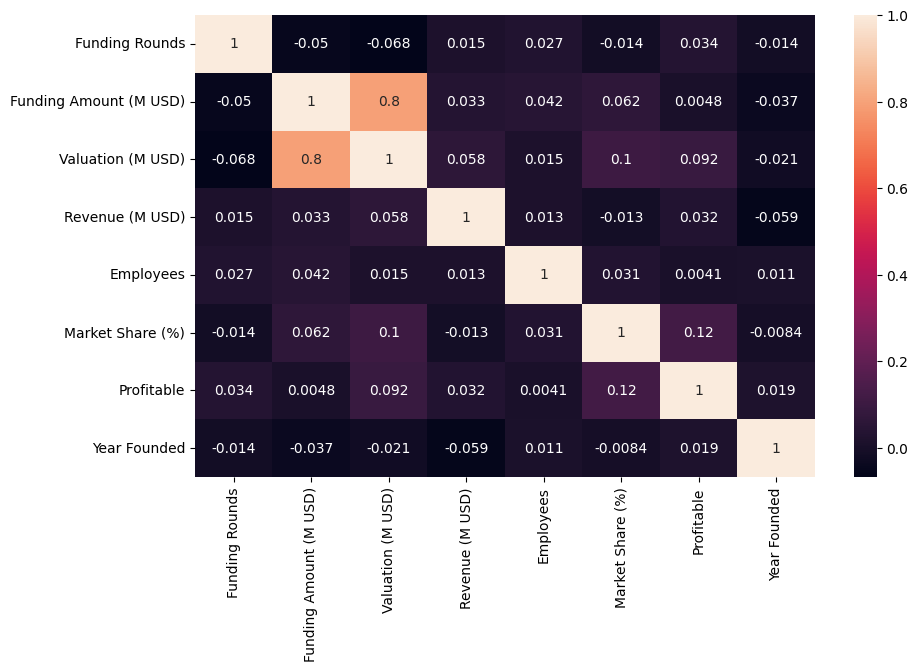

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True)

plt.show()


In [23]:
from scipy.stats import ttest_ind

# The column 'Funding_Status' does not exist. It has been replaced with 'Exit Status'.
# 'Founder_Experience' also does not exist. Using 'Funding Amount (M USD)' as a placeholder
# for demonstration. Please replace 'Funding Amount (M USD)' with the actual column
# you intended for 'Founder_Experience'.

funded_group = df[df['Exit Status']=="Acquired"]['Funding Amount (M USD)']
notfunded_group = df[df['Exit Status']=="Private"]['Funding Amount (M USD)']

# Perform t-test only if both groups have enough samples
if len(funded_group) > 1 and len(notfunded_group) > 1:
    t_stat, p_value = ttest_ind(funded_group, notfunded_group)
    print("P-value:", p_value)
else:
    print("Not enough data in one or both groups to perform t-test.")

P-value: 0.30366024371485023


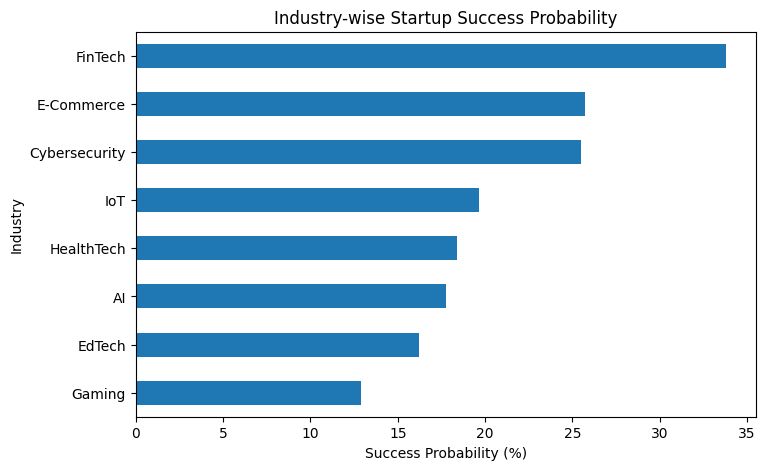

In [24]:
# Create a binary column for 'Acquired' status
df['Is_Acquired'] = (df['Exit Status'] == 'Acquired').astype(int)

# Group by 'Industry' and calculate the mean of 'Is_Acquired' for success probability
industry_prob = df.groupby('Industry')['Is_Acquired'].mean() * 100

industry_prob.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Industry-wise Startup Success Probability")
plt.xlabel("Success Probability (%)")
plt.show()

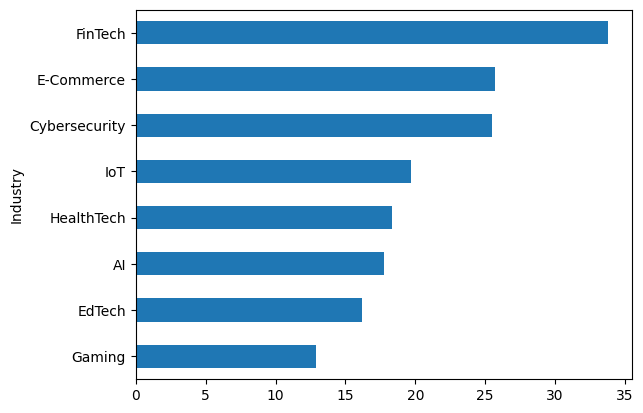

In [19]:
industry_prob.sort_values().plot(kind='barh')
plt.show()

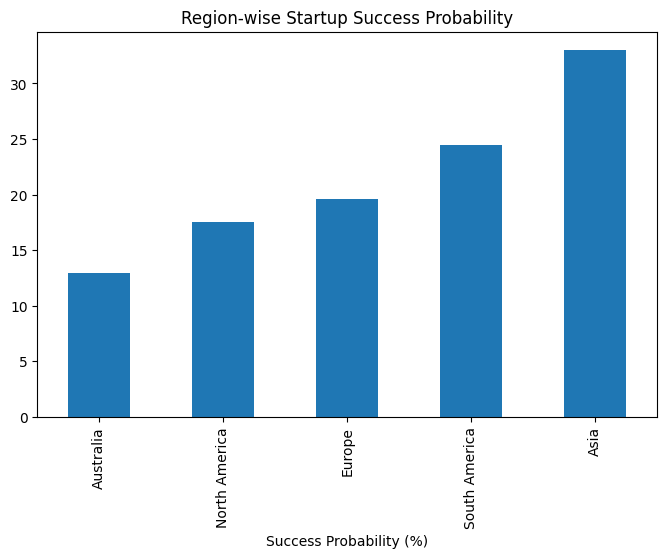

In [25]:
# Group by 'Region' and calculate the mean of 'Is_Acquired' for success probability
region_prob = df.groupby('Region')['Is_Acquired'].mean() * 100

region_prob.sort_values().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Region-wise Startup Success Probability")
plt.xlabel("Success Probability (%)")
plt.show()

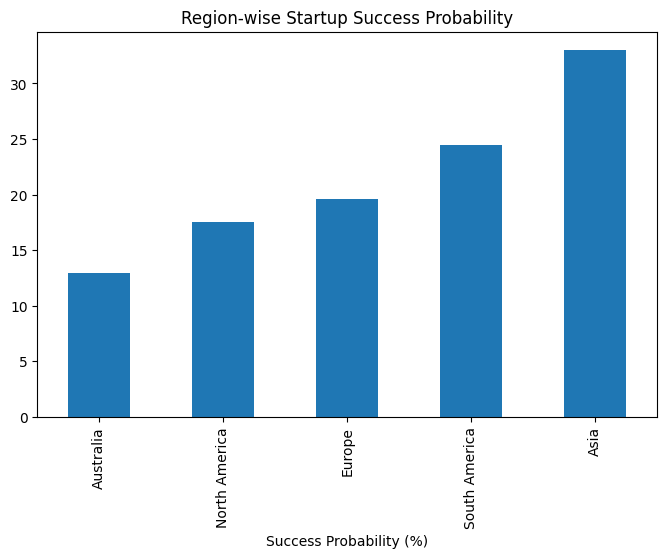

In [28]:
import matplotlib.pyplot as plt

# The previous plt.show() call closes the figure, so we need to regenerate the plot before saving.
# 'region_prob' was already calculated in cell '4cCtZbp4U2L4' and is available in the kernel.
region_prob.sort_values().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Region-wise Startup Success Probability")
plt.xlabel("Success Probability (%)")

# Save the plot to a file
plt.savefig('region_success.png')

# Optional: display the plot again if desired
plt.show()

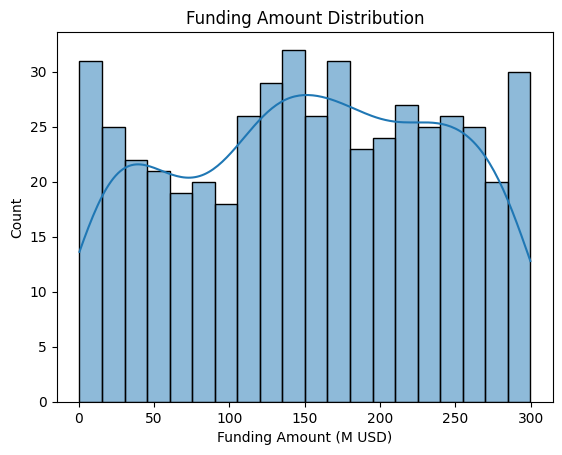

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    df['Funding Amount (M USD)'],
    bins=20,
    kde=True
)

plt.title("Funding Amount Distribution")
plt.show()

In [1]:
# %%writefile nu potta Colab-la pudsu text file create aagidum
%%writefile requirements.txt
pandas
numpy
matplotlib
seaborn
scikit-learn
jupyter

Writing requirements.txt


In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('startup_data (1).csv')
df = df.drop_duplicates()
df.fillna(df.median(numeric_only=True), inplace=True)
df['Is_Acquired'] = (df['Exit Status'] == 'Acquired').astype(int)

df_cleaned = pd.get_dummies(df.drop(columns=['Startup Name', 'Exit Status']), drop_first=True)

# 2. X (Features) matrum y (Target) split panrom
# Based on the context, 'Is_Acquired' is the binary indicator of success, likely intended as the target variable.
X = df_cleaned.drop('Is_Acquired', axis=1) # Drop the target variable from features
y = df_cleaned['Is_Acquired'] # Set 'Is_Acquired' as the target

# 3. Train & Test set-ah 80-20 ratio-la pirikirom
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Random Forest Model Create panni Train panrom
model = RandomForestRegressor(random_state=42) # A RandomForestClassifier might be more appropriate for a binary target
model.fit(X_train, y_train)

# 5. Predict panni Accuracy metrics check panrom
y_pred = model.predict(X_test)
print("--- Model Performance ---")
print(f"R2 Score: {r2_score(y_test, y_pred):.2f}")

--- Model Performance ---
R2 Score: -0.13
